
# Section Split Optimizer — Frozen Courses + Robust Pair Guards

*Patched on:* 2025-08-25 05:50:18

This version adds:
- `FROZEN_COURSES`: courses that will **not be split** (all students assigned to A).
- Robust guards so we **skip pairs** that aren't present in `pair_cells` (avoids `KeyError` when datasets are filtered).


In [ ]:

import pandas as pd
import numpy as np
import random
from collections import defaultdict
import math
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
EXCEL_PATH = "Term 6 Consolidated.xlsx"  # <-- change if needed

ID_COL = "Student Ids"
NAME_COL = "Student Names"

IGNORE_SHEETS = {"Sheet1"}

# Courses that should stay in ONE section (no A/B split)
FROZEN_COURSES = ["MKSEE01", "MKHRE01", "HRSEE01", "OMISE01", "ISSEE01", "HRLAE03", "MKISE03"]  # example course names

RESTARTS = 50
MAX_SWEEPS = 2000
ALLOW_IMBALANCE = 1
BASE_SEED = 42

print("Loaded config.")


Loaded config.


In [2]:

# Load sheets
xls = pd.ExcelFile(EXCEL_PATH)
courses = [s for s in xls.sheet_names if s not in IGNORE_SHEETS]
raw = {c: pd.read_excel(xls, sheet_name=c) for c in courses}

def norm_cols(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    return df

raw = {c: norm_cols(df) for c, df in raw.items()}

for c, df in raw.items():
    if ID_COL not in df.columns:
        raise ValueError(f"Sheet '{c}' is missing required column: '{ID_COL}'")

course_students = {}
course_student_ids = {}
for c, df in raw.items():
    df = df.dropna(subset=[ID_COL])
    df = df.drop_duplicates(subset=[ID_COL])
    course_students[c] = df[[ID_COL] + [col for col in [NAME_COL] if col in df.columns]].copy()
    course_student_ids[c] = df[ID_COL].astype(str).str.strip().tolist()

# Build student->courses ONLY from the currently active course_student_ids
student_to_courses = defaultdict(list)
for c, ids in course_student_ids.items():
    for sid in ids:
        student_to_courses[sid].append(c)

print(f"Courses loaded: {len(courses)} | Unique students: {len(student_to_courses)}")


Courses loaded: 15 | Unique students: 437


In [3]:

def balanced_initial_assignment(ids, allow_imbalance=1, rng=None):
    if rng is None:
        rng = random.Random()
    ids = list(ids)
    rng.shuffle(ids)
    half = len(ids) // 2
    assign = {}
    for i, sid in enumerate(ids):
        assign[sid] = 0 if i < half else 1
    return assign

def build_pair_key(a, b):
    return (a, b) if a < b else (b, a)

def count_nonzero_cells(arr):
    return int((arr > 0).sum())

def compute_pairwise_cells(course_names, course_student_ids, assignments):
    pair_cells = {}
    for i in range(len(course_names)):
        c1 = course_names[i]
        ids1 = set(course_student_ids[c1])
        a1 = assignments[c1]
        for j in range(i+1, len(course_names)):
            c2 = course_names[j]
            ids2 = set(course_student_ids[c2])
            inter = ids1 & ids2
            arr = np.zeros((2,2), dtype=int)
            if inter:
                a2 = assignments[c2]
                for sid in inter:
                    # guard: sid should exist in both assignments (true if data consistent)
                    if sid in a1 and sid in a2:
                        arr[a1[sid], a2[sid]] += 1
            pair_cells[(c1, c2)] = arr
    return pair_cells

def compute_objective(pair_cells):
    return sum(count_nonzero_cells(arr) for arr in pair_cells.values())

def try_improve(assignments, pair_cells, course_student_ids, student_to_courses, allow_imbalance=1, rng=None, frozen_courses=None):
    if rng is None:
        rng = random.Random()
    if frozen_courses is None:
        frozen_courses = set()

    improved_any = False
    total_delta = 0

    course_list = list(course_student_ids.keys())
    rng.shuffle(course_list)

    for c in course_list:
        if c in frozen_courses:
            continue  # don't move students in frozen courses

        ids = list(course_student_ids[c])
        rng.shuffle(ids)

        amap = assignments[c]
        nA = sum(1 for v in amap.values() if v == 0)
        nB = sum(1 for v in amap.values() if v == 1)

        for sid in ids:
            if sid not in amap:
                continue
            cur = amap[sid]
            new = 1 - cur

            new_nA = nA + (1 if new==0 else -1)
            new_nB = nB + (1 if new==1 else -1)
            if abs(new_nA - new_nB) > allow_imbalance:
                continue

            delta = 0
            affected_pairs = []
            for d in student_to_courses[sid]:
                if d == c or d not in assignments:
                    continue
                key = build_pair_key(c, d)
                arr = pair_cells.get(key)
                if arr is None:
                    # If pair_cells lacks this key, skip safely
                    continue
                d_label = assignments[d].get(sid)
                if d_label is None:
                    continue

                before_nonzero = count_nonzero_cells(arr)
                arr[cur, d_label] -= 1
                arr[new, d_label] += 1
                after_nonzero = count_nonzero_cells(arr)
                affected_pairs.append((key, cur, new, d_label))
                delta += (after_nonzero - before_nonzero)

            if delta < 0:
                amap[sid] = new
                nA, nB = new_nA, new_nB
                improved_any = True
                total_delta += delta
            else:
                for key, curv, newv, d_label in affected_pairs:
                    arr = pair_cells[key]
                    arr[newv, d_label] -= 1
                    arr[curv, d_label] += 1

    return improved_any, total_delta

def optimize_splits(course_student_ids, student_to_courses, allow_imbalance=1, restarts=5, max_sweeps=20, base_seed=None, frozen_courses=None):
    if frozen_courses is None:
        frozen_courses = set()

    course_names = list(course_student_ids.keys())

    best_assignments = None
    best_pair_cells = None
    best_obj = math.inf
    history = []

    for r in range(restarts):
        seed = (None if base_seed is None else base_seed + r)
        rng = random.Random(seed)

        assignments = {}
        for c, ids in course_student_ids.items():
            if c in frozen_courses:
                assignments[c] = {sid: 0 for sid in ids}  # all in A
            else:
                assignments[c] = balanced_initial_assignment(ids, allow_imbalance, rng)

        pair_cells = compute_pairwise_cells(course_names, course_student_ids, assignments)
        obj = compute_objective(pair_cells)
        start_obj = obj

        for sweep in range(max_sweeps):
            improved, delta = try_improve(assignments, pair_cells, course_student_ids, student_to_courses,
                                          allow_imbalance, rng, frozen_courses=frozen_courses)
            obj += delta
            if not improved:
                break

        history.append((r, start_obj, obj))

        if obj < best_obj:
            best_obj = obj
            best_assignments = assignments
            best_pair_cells = {k: v.copy() for k, v in pair_cells.items()}

    return best_assignments, best_pair_cells, best_obj, history


In [4]:

# Run optimization
assignments, pair_cells, obj, hist = optimize_splits(
    course_student_ids=course_student_ids,
    student_to_courses=student_to_courses,
    allow_imbalance=ALLOW_IMBALANCE,
    restarts=RESTARTS,
    max_sweeps=MAX_SWEEPS,
    base_seed=BASE_SEED,
    frozen_courses=set(FROZEN_COURSES)
)
print("Optimization complete.")
print("History (restart_index, start_obj, final_obj):")
for h in hist:
    print(h)
print("Best final objective (#non-zero cells across all 2x2 overlaps):", obj)


Optimization complete.
History (restart_index, start_obj, final_obj):
(0, 243, 242)
(1, 245, 243)
(2, 245, 244)
(3, 242, 239)
(4, 243, 242)
Best final objective (#non-zero cells across all 2x2 overlaps): 239


Sections shown: 23
Zero cells: 28 | Non-zero cells: 478 | Zero ratio: 5.53%
Max overlap in any shown section-pair: 21
Saved: /mnt/data/section_pair_overlap_frozen_safe.csv


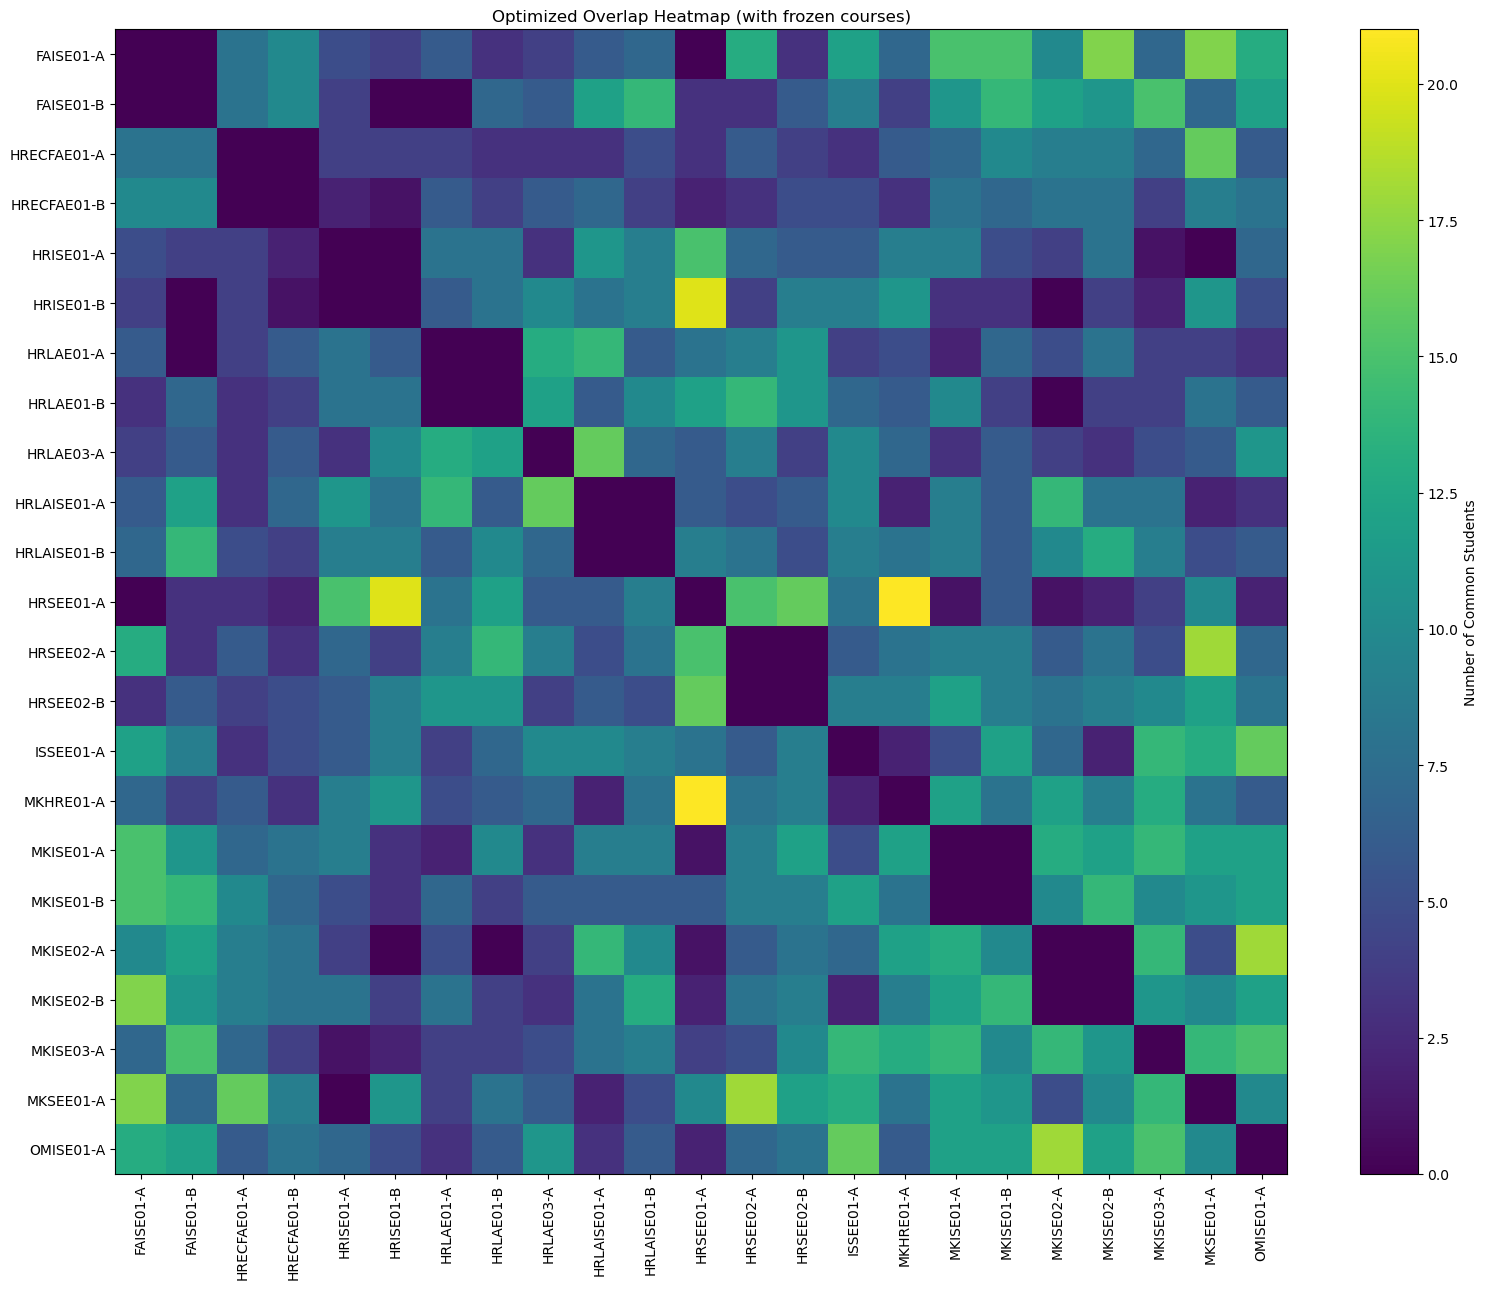

Saved: /mnt/data/optimized_heatmap_frozen_safe.png


In [5]:

# Build section x section matrix for visualization
all_sections = []
for c in courses:
    if c in set(FROZEN_COURSES):
        all_sections.append(f"{c}-A")
    else:
        all_sections.extend([f"{c}-A", f"{c}-B"])

index_map = {sec:i for i, sec in enumerate(all_sections)}
mat = np.zeros((len(all_sections), len(all_sections)), dtype=int)

for (c1, c2), arr in pair_cells.items():
    # handle frozen single-section courses
    c1_keys = [f"{c1}-A"] if c1 in set(FROZEN_COURSES) else [f"{c1}-A", f"{c1}-B"]
    c2_keys = [f"{c2}-A"] if c2 in set(FROZEN_COURSES) else [f"{c2}-A", f"{c2}-B"]

    # arr is 2x2; if frozen, only row 0 or col 0 is meaningful
    for i1, k1 in enumerate(c1_keys):
        for i2, k2 in enumerate(c2_keys):
            i = index_map[k1]
            j = index_map[k2]
            # map into arr indices: frozen uses row/col 0
            r = 0 if c1 in set(FROZEN_COURSES) else i1
            c = 0 if c2 in set(FROZEN_COURSES) else i2
            mat[i, j] = arr[r, c]
            mat[j, i] = arr[r, c]

# Compute metrics
# Only count cells corresponding to actual pairs built (we approximate using all off-diagonals)
non_diag = np.ones_like(mat, dtype=bool)
np.fill_diagonal(non_diag, False)
nonzeros = int((mat[non_diag] > 0).sum())
total_cells = int(non_diag.sum())
zeros = total_cells - nonzeros
max_overlap = int(mat[np.triu_indices_from(mat, k=1)].max()) if mat.size else 0

print(f"Sections shown: {len(all_sections)}")
print(f"Zero cells: {zeros} | Non-zero cells: {nonzeros} | Zero ratio: {zeros/total_cells:.2%}")
print(f"Max overlap in any shown section-pair: {max_overlap}")

# Save CSV
sec_df = pd.DataFrame(mat, index=all_sections, columns=all_sections)
sec_df.to_csv("section_pair_overlap_frozen_safe.csv")
print("Saved: /mnt/data/section_pair_overlap_frozen_safe.csv")

# Plot heatmap using matplotlib (no seaborn/colors)
plt.figure(figsize=(16, 13))
plt.imshow(mat, aspect='auto')
plt.colorbar(label='Number of Common Students')
plt.xticks(range(len(all_sections)), all_sections, rotation=90)
plt.yticks(range(len(all_sections)), all_sections)
plt.title("Optimized Overlap Heatmap (with frozen courses)")
plt.tight_layout()
plt.savefig("optimized_heatmap_frozen_safe.png", dpi=200)
plt.show()
print("Saved: /mnt/data/optimized_heatmap_frozen_safe.png")


In [6]:

# Export assignments to Excel
writer_path = "optimized_section_splits_frozen_safe.xlsx"
with pd.ExcelWriter(writer_path, engine="xlsxwriter") as writer:
    rows = []
    for c, df in course_students.items():
        amap = assignments[c]
        for _, row in df.iterrows():
            sid = str(row.get(ID_COL, "")).strip()
            if sid in amap:
                sec = "A" if amap[sid]==0 else "B"
                out = {"Course": c, ID_COL: sid, "Section": sec}
                if NAME_COL in df.columns:
                    out[NAME_COL] = row.get(NAME_COL, "")
                rows.append(out)
    assign_df = pd.DataFrame(rows)
    assign_df = assign_df[[col for col in ["Course", ID_COL, "Section", NAME_COL] if col in assign_df.columns]]
    assign_df.to_excel(writer, sheet_name="Assignments", index=False)

    for c, df in course_students.items():
        amap = assignments[c]
        maskA = df[ID_COL].astype(str).str.strip().map(lambda x: amap.get(x, 0)) == 0
        dfA = df[maskA].copy()
        dfA.to_excel(writer, sheet_name=f"{c}-A", index=False)
        if c not in set(FROZEN_COURSES):
            maskB = df[ID_COL].astype(str).str.strip().map(lambda x: amap.get(x, 0)) == 1
            dfB = df[maskB].copy()
            dfB.to_excel(writer, sheet_name=f"{c}-B", index=False)

print(f"Saved: {writer_path}")


Saved: optimized_section_splits_frozen_safe.xlsx
